In [1]:
from homicsx import(
    GeometryInput, 
    PhysicalTags, 
    MeshSettings, 
    LinearElasticIsotropic, 
    MaterialAssignment, 
    ProblemSettings
)
from homicsx.geometry import patriculate_geometry_generator
from homicsx.visualization import visualize_geometry
from homicsx.mesh import generate_mesh
from homicsx.homogenization.driver import LinearHomogenizationDriver
from homicsx.utils import (
    extract_effective_moduli_2d_plane_strain, 
    mori_tanaka,
    hashin_shtrikman,
)

import numpy as np

Generate 2D mono-disperse unit-cell geometry with spherical inclusions

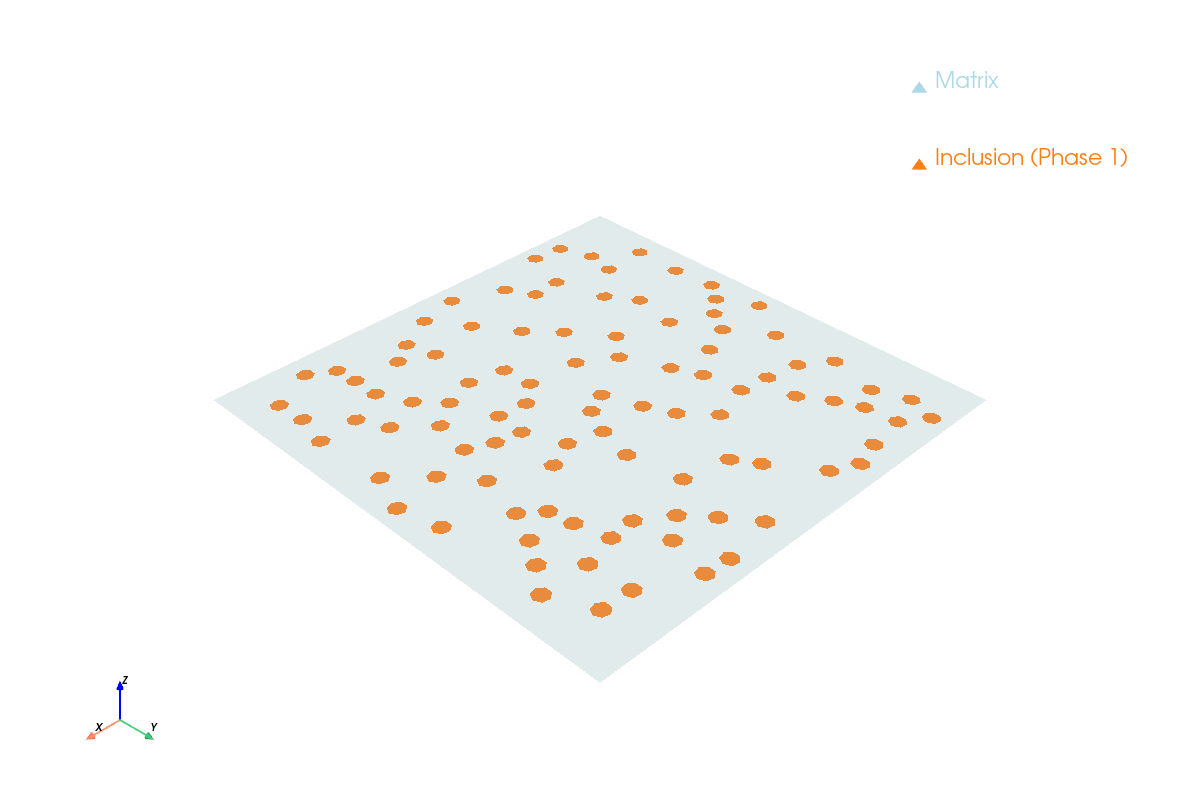

In [2]:
geometry_input = GeometryInput(
    dim=2,
    dispersion="mono",
    volume_fraction=0.1,
    num_particles=100,
    clearance=0.015,
    domain_size=(1, 1),
    shape="circle",
    seed=42,
)

geometry = patriculate_geometry_generator(geometry_input)

visualize_geometry(geometry)

Generate physical tagging convention, mesh settings, and the mesh entities, including the DOLFINx mesh, and DOLFINx compatible cell tags and facet tags

In [3]:
physical_tags = PhysicalTags()

mesh_settings = MeshSettings(
    min_size=0.01,
    max_size=0.02,
    physical_tags=physical_tags,
)

mesh, ct, ft = generate_mesh(
    geometry=geometry,
    mesh_settings=mesh_settings,
)

Defining the material assignment

In [4]:
E_mat = 1.0
nu_mat = 0.2
mat_matrix = LinearElasticIsotropic(young_modulus=E_mat, poisson_ratio=nu_mat)

E_inc = 50.0
nu_inc = 0.2
mat_particle = LinearElasticIsotropic(young_modulus=E_inc, poisson_ratio=nu_inc)

material_assignment = MaterialAssignment(
    materials_by_phase={
        0: mat_matrix,
        1: mat_particle,
    }
)

Preparing the FEM solver settings

In [5]:
fem_settings = ProblemSettings(
    dim = geometry_input.dim,
    kinematics='small_strain',
    two_dimensional_formulation='plane_strain',
    element_family='Lagrange',
    element_degree=1,
    petsc_options = {
        "ksp_type": "preonly",
        "pc_type": "lu",
        "pc_factor_mat_solver_type": "mumps",
    },
)

Solving the corresponding homogenization problem

In [6]:
linear_driver = LinearHomogenizationDriver(
    mesh_obj=mesh,
    cell_tags=ct,
    facet_tags=ft,
    assignment=material_assignment,
    settings=fem_settings,
    physical_tags=physical_tags,
    domain_size=geometry_input.domain_size,
    matrix_phase_id=0,
    mode='complete',
)
result = linear_driver.run()

Post-processing the results

In [7]:
C_hom_mt = mori_tanaka(
    E_m=E_mat,
    nu_m=nu_mat,
    E_f=E_inc,
    nu_f=nu_inc,
    vol_f=geometry_input.volume_fraction,
    dim=2,
)

C_hom = result.C_hom
print('C_hom: ')
with np.printoptions(suppress=True, precision=3):
    print(C_hom)

print('\nC_hom_mt: ')
with np.printoptions(suppress=True, precision=3):
    print(C_hom_mt)

kappa_mt, mu_mt, E_mt, nu_mt = extract_effective_moduli_2d_plane_strain(C_hom_mt)
kappa_hom, mu_hom, E_hom, nu_hom = extract_effective_moduli_2d_plane_strain(C_hom)

hs_bounds = hashin_shtrikman(
    E_m=E_mat,
    nu_m=nu_mat,
    E_f=E_inc,
    nu_f=nu_inc,
    vol_f=geometry_input.volume_fraction,
    dim=2,
)

E_hs_lower = hs_bounds['E'][0]
E_hs_upper = hs_bounds['E'][1]

print('\nsummary:')
print('-'*20)
print('Young modulus:')
print(f'homogenization result: {E_hom}')
print(f'Mori-Tanaka estimate: {E_mt}')
print(f'Hashin-Shtrikman upper bound: {E_hs_upper}')
print(f'Hashin-Shtrikman lower bound: {E_hs_lower}')
print('-'*20)
print('Poison ratio:')
print(f'homogenization result: {nu_hom}')
print(f'Mori-Tanaka estimate: {nu_mt}')

C_hom: 
[[ 1.296  0.328  0.   ]
 [ 0.328  1.297 -0.002]
 [-0.    -0.002  0.484]]

C_hom_mt: 
[[1.458 0.392 0.   ]
 [0.392 1.458 0.   ]
 [0.    0.    0.637]]

summary:
--------------------
Young modulus:
homogenization result: 1.213331545883906
Mori-Tanaka estimate: 1.5733882155362948
Hashin-Shtrikman upper bound: 2.8761296164484844
Hashin-Shtrikman lower bound: 1.2072343940600005
--------------------
Poison ratio:
homogenization result: 0.25322695362141434
Mori-Tanaka estimate: 0.23511321939496677
